<a href="https://colab.research.google.com/github/myasym/carisurg-portfolio/blob/main/week_0/day_2_rr_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Respiratory Rate Data Cleaning - Week 0, Assignment 2**

Contributors - Tyler Baksh , Kaylah Leigertwood-Ollivierre , Mya Symister , Sariana Ramoutar , Zhanna McDonald , Sekou Ruddock

In [64]:
# 1. Environment Check
#Confirm Python version >= 3.10
import sys
print(f'Python version: {sys.version}')

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [65]:
# 2. Import Libraries
import pandas as pd             # Data handling
import numpy as np              # Numerical operations (NaNs, Arrays)
import matplotlib.pyplot as plt # Visualisation

print('Libraries imported successfully!')

Libraries imported successfully!


In [66]:
# 3. Load Dataset
FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

try:
    df = pd.read_csv(FILE_PATH)
    print("Dataset successfully loaded!")
except FileNotFoundError:
    raise FileNotFoundError(f"File not found at path: {FILE_PATH}")

# Basic structure check
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Dataset successfully loaded!
Shape: 2205 rows x 11 columns
Columns: ['ID', 'Age', 'Gender', 'GCS', 'SBP', 'DBP', 'MAP', 'pulse', 'Temp', 'RR', 'Fio2']


In [67]:
# 4. Respiratory Rate (RR) Cleaning
COLUMN = 'RR'   # RR = Respiratory Rate (breaths per minute)
VALID_MIN = 5   # Clinically plausible min RR
VALID_MAX = 60  # Clinically plausible max RR
                # Values outside this range are likely data entry errors or outliers needing further investigation

# 4.1 Initial Inspection
print("\nInitial unique values (sample):")
print(df[COLUMN].unique()[:15])

print(f"\nInitial data type: {df[COLUMN].dtype}")

# Count missing BEFORE conversion
missing_before = df[COLUMN].isnull().sum()
print(f"Missing values before conversion: {missing_before}")


Initial unique values (sample):
[14. 16. 18. 12. 19. 20. 25. 15. 24. nan 30. 29. 40. 26. 38.]

Initial data type: float64
Missing values before conversion: 22


In [68]:
# 4.2 Convert to Numeric
# Invalid entries (e.g., strings) will become NaN
df[COLUMN] = pd.to_numeric(df[COLUMN], errors='coerce')

# Column remains float because:
# 1. NaN values require float dtype in pandas
# 2. Median/mean imputation may produce non-integer values

missing_after = df[COLUMN].isnull().sum()

print(f"Missing values after conversion: {missing_after}")
print(f"New NaNs introduced: {missing_after - missing_before}")

print("\nSummary statistics after conversion:")
print(df[COLUMN].describe())

Missing values after conversion: 22
New NaNs introduced: 0

Summary statistics after conversion:
count    2183.000000
mean       20.262254
std         5.742333
min        12.000000
25%        17.000000
50%        18.000000
75%        21.000000
max        50.000000
Name: RR, dtype: float64


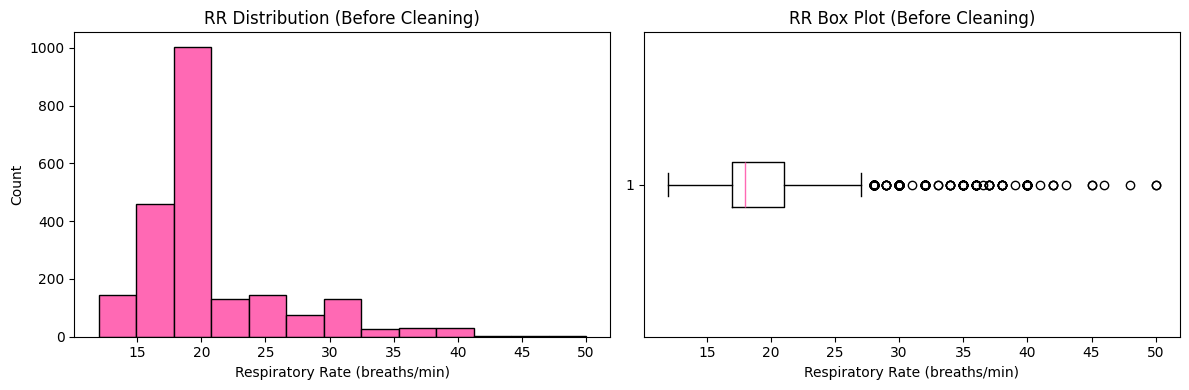

In [69]:
# 4.3 Visualisation BEFORE Cleaning
# This helps spot data entry errors & outliers, and visualise what a typical repiratory rate looks like for patients
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df[COLUMN].dropna(), bins=13, edgecolor='black', color='hotpink')
axes[0].set_xlabel('Respiratory Rate (breaths/min)')
axes[0].set_ylabel('Count')
axes[0].set_title('RR Distribution (Before Cleaning)')

# Boxplot
axes[1].boxplot(df[COLUMN].dropna(), vert=False, medianprops=dict(color='hotpink'))
axes[1].set_xlabel('Respiratory Rate (breaths/min)')
axes[1].set_title('RR Box Plot (Before Cleaning)')

plt.tight_layout()
plt.savefig('rr_distribution_before.png', dpi=100)
plt.show()

In [70]:
# 4.4 Identify Out-of-Range Values
invalid_mask = (df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX)
invalid_values = df[invalid_mask]

print(f"\nOut-of-range values detected: {len(invalid_values)}")

# Replace invalid values with NaN
df.loc[invalid_mask, COLUMN] = np.nan


Out-of-range values detected: 0


In [71]:
# 4.5 Investigate Edge (High but Valid) Values
high_rr = df[df[COLUMN] > 30]
print(f"High RR values (>30 breaths/min): {len(high_rr)}")

High RR values (>30 breaths/min): 131


In [72]:
# 4.6 Imputation
# Median is chosen due to right-skew (mean > median)
median_value = df[COLUMN].median()
print(f"Median RR used for imputation: {median_value}")

df[COLUMN] = df[COLUMN].fillna(median_value)

Median RR used for imputation: 18.0


In [73]:
# 4.7 Validation Checks
assert df[COLUMN].isnull().sum() == 0, "Error: Missing values remain after imputation!"
assert df[COLUMN].between(VALID_MIN, VALID_MAX).all(), "Error: Invalid RR values still present!"

In [74]:
# 4.8 Feature Engineering (Semantic Labels)
def rr_category(rr):
    if rr < 12:
        return 'Low'
    elif 12 <= rr <= 20:
        return 'Normal'
    elif 21 <= rr <= 30:
        return 'Elevated'
    else:
        return 'Critical'

df['RR_Category'] = df[COLUMN].apply(rr_category)

# NOTE:
# RR categories are used for illustrative purposes only and are not clinically validated.
# In practice, thresholds should be confirmed with clinical stakeholders (e.g., ED clinicians and healthcare analytics teams).

In [75]:
# 4.9 Final Summary
print("\n=== After Cleaning ===")
print(df[COLUMN].describe())
print(f"Remaining missing values: {df[COLUMN].isnull().sum()}")

print("\nRR Category Distribution:")
print(df['RR_Category'].value_counts())


=== After Cleaning ===
count    2205.000000
mean       20.239683
std         5.718026
min        12.000000
25%        17.000000
50%        18.000000
75%        21.000000
max        50.000000
Name: RR, dtype: float64
Remaining missing values: 0

RR Category Distribution:
RR_Category
Normal      1629
Elevated     445
Critical     131
Name: count, dtype: int64


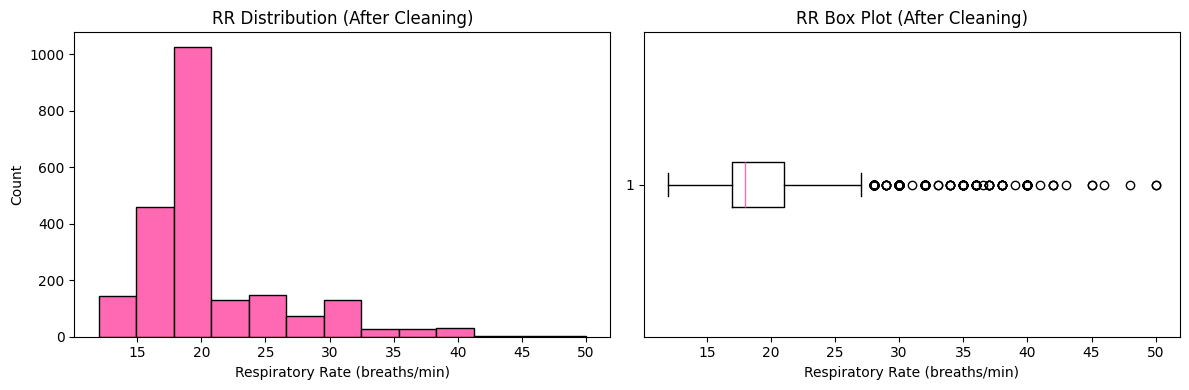


Cleaning process completed successfully.


In [76]:
# 4.10 Visualisation AFTER Cleaning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[COLUMN], bins=13, edgecolor='black', color='hotpink')
axes[0].set_xlabel('Respiratory Rate (breaths/min)')
axes[0].set_ylabel('Count')
axes[0].set_title('RR Distribution (After Cleaning)')

axes[1].boxplot(df[COLUMN], vert=False, medianprops=dict(color='hotpink'))
axes[1].set_xlabel('Respiratory Rate (breaths/min)')
axes[1].set_title('RR Box Plot (After Cleaning)')

plt.tight_layout()
plt.savefig('rr_distribution_after.png', dpi=100)
plt.show()

print("\nCleaning process completed successfully.")

## Reflection

In this task, I worked in a group to clean and prepare the Respiratory Rate (RR) variable from an emergency triage dataset, ensuring it was suitable for further analysis.

### Improvements I made to my original approach
Compared to my earlier work, I improved the robustness of my pipeline by:
- Explicitly tracking missing values before and after conversion
- Adding validation checks to ensure no invalid values remained after cleaning
- Separating each stage of the cleaning process more clearly (conversion, validation, imputation)
- Improving visualisation by clearly separating “before” and “after” plots
- Adding a semantic categorisation of RR values (Low, Normal, Elevated, Critical) to make the data more interpretable

### What I learned
This exercise helped me understand that data cleaning is not just about removing bad values, but about documenting decisions, justifying methods, and ensuring reproducibility. I also learned the importance of checking assumptions, such as distribution shape, before choosing imputation methods.
